[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AstroAI-CfA/tutorial-lsdb/blob/main/tutorials/Notebook_3_Solution.ipynb)

Author: Konstantin Malanchev and the LINCC Frameworks team

Last updated: June 2026

## Solution to Problem 3

### Find a Transient with BazinFit

We fit the Bazin function to every ZTF DR24 object in a 20-arcmin cone around RA = 206 deg, Dec = +61.5 deg, and identify the object whose lightcurve most resembles a transient.

In [1]:
# do you need to install the packages?
# if yes, uncomment the line below and restart the kernel
# %pip install -U lsdb nested-pandas light-curve s3fs

In [2]:
import logging
import warnings

import dask
import light_curve as licu
import lsdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from dask.distributed import Client
from lsdb import ConeSearch
from matplotlib import rcParams

%matplotlib inline
warnings.simplefilter("ignore")
logging.getLogger("distributed").setLevel(logging.WARNING)
rcParams["savefig.dpi"] = 150
rcParams["font.size"] = 14
plt.rc("font", family="serif")
mpl.rcParams["axes.linewidth"] = 1.5
dask.config.set({"dataframe.convert-string": False})

In [3]:
client = Client(n_workers=2, memory_limit="4GiB", threads_per_worker=1)
print(f"Dask is running at: {client.dashboard_link}")

Dask is running at: http://127.0.0.1:59532/status


### Load ZTF DR24 in the target cone

In [4]:
ZTF_PATH = "s3://ipac-irsa-ztf/ztf/enhanced/dr24/lc/hats/"
cone = ConeSearch(ra=206.0, dec=61.5, radius_arcsec=20 * 60)

ztf = lsdb.open_catalog(ZTF_PATH, search_filter=cone)
ztf = ztf.query("lightcurve.catflags == 0")
ztf = ztf.query("lightcurve.len() >= 100")
ztf

,objectid,filterid,objra,objdec,lightcurve
npartitions=1,,,,,
"Order: 5, Pixel: 2956",int64[pyarrow],int8[pyarrow],float[pyarrow],float[pyarrow],"nested<hmjd: [double], mag: [float], magerr: [..."


### Filter by peak magnitude and variability

We keep objects with peak magnitude brighter than 20, and also filter by ReducedChi2.

In [5]:
chi2_feat = licu.ReducedChi2()

ztf = ztf.map_rows(
    lambda row: {
        "peak_mag": row["lightcurve.mag"].min(),
        "r_chi2": chi2_feat(row["lightcurve.hmjd"].astype(np.float32), row["lightcurve.mag"], row["lightcurve.magerr"])[0],
    },
    meta={"peak_mag": np.float32, "r_chi2": np.float32},
    append_columns=True,
)
ztf = ztf.query("peak_mag < 20 and r_chi2 > 10.0")

### Add time column and convert magnitudes to flux

The Bazin function rises in flux, so we work with fluxes, we are using μJy: $f = 10^{-0.4\,(m-23.9)}$, $\sigma_f = f \ln(10) \cdot 0.4 \cdot \sigma_m$.

In [6]:
def add_flux_columns(part):
    flux = 10 ** (-0.4 * (part["lightcurve.mag"] - 23.9))
    part["lightcurve.time"] = part["lightcurve.hmjd"] - 60_000
    part["lightcurve.flux"] = flux
    part["lightcurve.fluxerr"] = flux * np.log(10) * 0.4 * part["lightcurve.magerr"]
    return part

ztf = ztf.map_partitions(add_flux_columns)

### Fit the Bazin function with `map_rows`

In [7]:
bazin = licu.BazinFit(algorithm="lmsder")
print(f"BazinFit feature names: {bazin.names}")

def fit_bazin(time, flux, fluxerr):
    result = bazin(time, flux, fluxerr)
    return dict(zip(bazin.names, result))

ztf = ztf.map_rows(
    fit_bazin,
    columns=["lightcurve.time", "lightcurve.flux", "lightcurve.fluxerr"],
    meta={name: np.float64 for name in bazin.names},
    row_container="args",
    append_columns=True,
)

BazinFit feature names: ['bazin_fit_amplitude', 'bazin_fit_baseline', 'bazin_fit_reference_time', 'bazin_fit_rise_time', 'bazin_fit_fall_time', 'bazin_fit_reduced_chi2']


### Compute and find the best transient candidate

In [8]:
%%time
df = ztf.compute()
df

CPU times: user 570 ms, sys: 200 ms, total: 770 ms
Wall time: 27.1 s


objectid  filterid       objra     objdec  \
_healpix_29                                                            
832182104941031826  821307100020209         3  205.434204  61.357094   
832182104941591245  821207100017628         2  205.434067  61.357155   
...                             ...       ...         ...        ...   
832107821905933411  821207100009203         2  206.226868  61.762356   
832109126181233445  821307100033242         3  206.054291  61.808777   

                                                           lightcurve  \
_healpix_29                                                             
832182104941031826  [{hmjd: 58232.32687, mag: 19.465748, magerr: 0...   
832182104941591245  [{hmjd: 58198.38638, mag: 19.936979, magerr: 0...   
...                                                               ...   
832107821905933411  [{hmjd: 58198.38634, mag: 21.057785, magerr: 0...   
832109126181233445  [{hmjd: 58232.32683, mag: 17.638746, magerr: 0...   

                     peak_mag     r_chi2  bazin_fit_amplitude  \
_healpix_29                                                     
832182104941031826  18.457823  13.109600             0.011444   
832182104941591245  18.113983  16.808479             6.092426   
...                       ...        ...                  ...   
832107821905933411  18.352003  13.877921          1479.339875   
832109126181233445  17.213560  15.607484            21.780409   

                    bazin_fit_baseline  bazin_fit_reference_time  \
_healpix_29                                                        
832182104941031826           64.314314              -1950.421163   
832182104941591245           53.218070              -2363.134528   
...                                ...                       ...   
832107821905933411           13.904387             -14390.533054   
832109126181233445          313.109503              -1383.578566   

                    bazin_fit_rise_time  bazin_fit_fall_time  \
_healpix_29                                                    
832182104941031826          3387.185512          4712.196225   
832182104941591245          5642.879438          1732.677496   
...                                 ...                  ...   
832107821905933411          1174.003277          2102.979309   
832109126181233445            53.586733          4579.776345   

                    bazin_fit_reduced_chi2  
_healpix_29                                 
832182104941031826               10.490977  
832182104941591245               10.872649  
...                                    ...  
832107821905933411                3.366591  
832109126181233445               13.741778  

[119 rows x 13 columns]

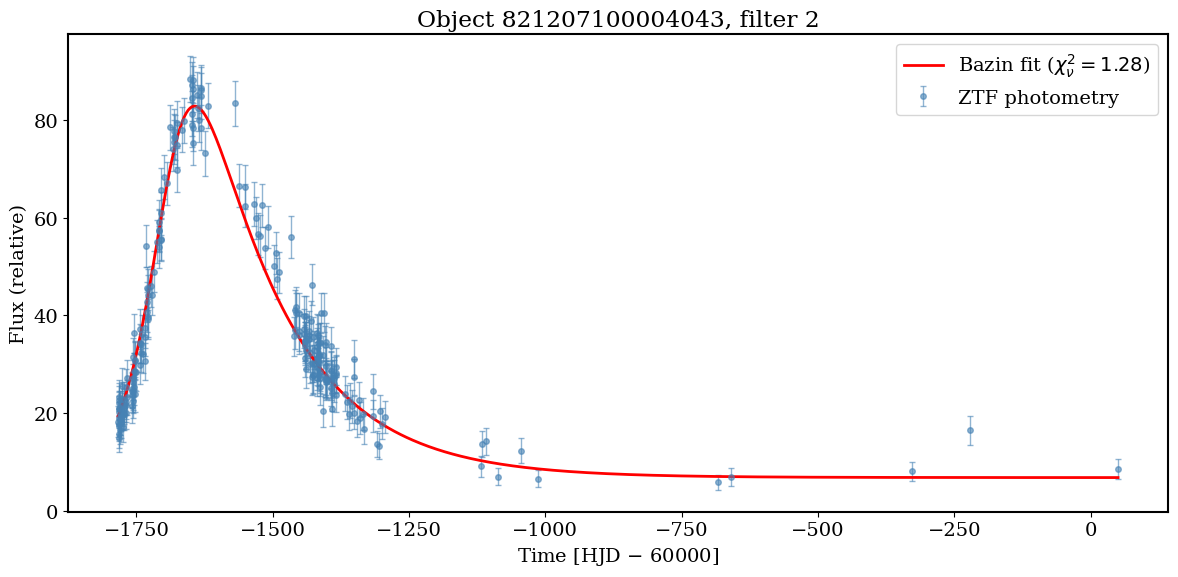

Check the object at the SNAD viewer: https://ztf.snad.space/view/821207100004043


In [10]:
row = df.iloc[np.argmin(df["bazin_fit_reduced_chi2"] / df["r_chi2"])]
lc_data = row["lightcurve"]

t_fit = np.linspace(lc_data["time"].min(), lc_data["time"].max(), 500)
params = np.array([row[name] for name in bazin.names])
flux_fit = licu.BazinFit.model(t_fit, params)

fig, ax = plt.subplots(figsize=(12, 6))
ax.errorbar(lc_data["time"], lc_data["flux"], yerr=lc_data["fluxerr"],
            fmt="o", color="steelblue", ecolor="steelblue",
            alpha=0.6, markersize=4, elinewidth=1, capsize=2, label="ZTF photometry")
ax.plot(t_fit, flux_fit, "r-", lw=2,
        label=fr"Bazin fit ($\chi^2_\nu={row["bazin_fit_reduced_chi2"]:.2f}$)")
ax.set_xlabel("Time [HJD $-$ 60000]")
ax.set_ylabel("Flux (relative)")
ax.set_title(f"Object {row['objectid']}, filter {row['filterid']}")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Check the object at the SNAD viewer: https://ztf.snad.space/view/{row['objectid']}")

In [ ]:
client.close()